In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [18]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [19]:
# creo un df

df = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura"])
df

,Nombre,Edad,Altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


In [20]:
df.describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


In [21]:

correlacion = df["Edad"].corr(df["Altura"])
correlacion


np.float64(-0.3292749795484255)

In [22]:
# -0.3292749795484255 es la correlación entre edad y altura
# correlación negativa, parece quea mayor edad, la altura tiende a ser ligeramente menor
# es una corr débil, la edad explica muy poca variabilidad en la altura
# es ddecir, la altura no depende de la edad, al menos en esta franja de edad, porque en los niños sí tiene que variar por narices

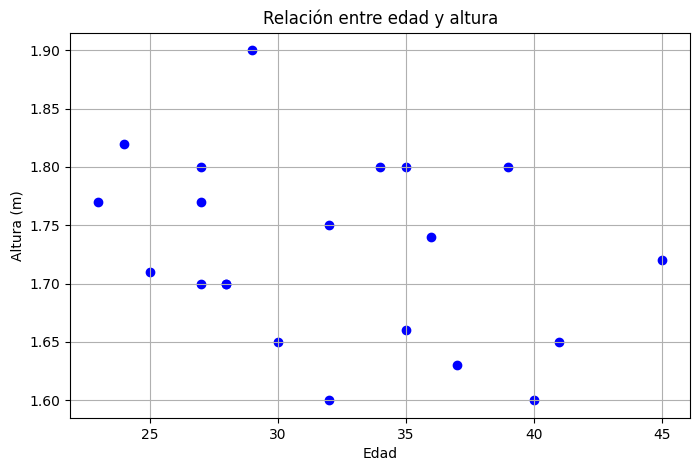

In [23]:

# vamos al scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df["Edad"], df["Altura"], color="blue")
plt.xlabel("Edad")
plt.ylabel("Altura (m)")
plt.title("Relación entre edad y altura")
plt.grid(True)
plt.show()


### Entrena un modelo de regresión lineal

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [25]:
X = df[["Edad"]]
y = df["Altura"]

modelo = LinearRegression()
modelo.fit(X, y)

print(modelo.coef_[0]) # este es el coeficiente, la pendiente, digamos
# coef es cuánto cambia la altura cuando la edad aumenta en 1 año
# si positivo, la altura aumenta con la edadç
# si cercano a 0, laedad prácticamente no afecta a la altura

print(modelo.intercept_) # intercepto es el valor donde la recta corta el eje Y
# es el valor de altura estimada cuando la edad = 0


-0.00427716271884655
1.8644194129763132


In [ ]:
# miro el coef:
# por cada año adicional de edad, la altura estimada disminuye en 0.004277 m
# es disminución muy pequeña e indica una relación débil y negativa
# el modelo detecta una ligera tendencia a que personas algo mayores sean un poco más bajas, pero la magnitud es tan pequeña que no tiene relevancia real


# miro el intercepto:
# el modelo 'cree' que si la edad fuera 0, la altura sería de1.86
# no tiene sentido biológicamente


# cone sta muestra la edad no predice la altura

c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


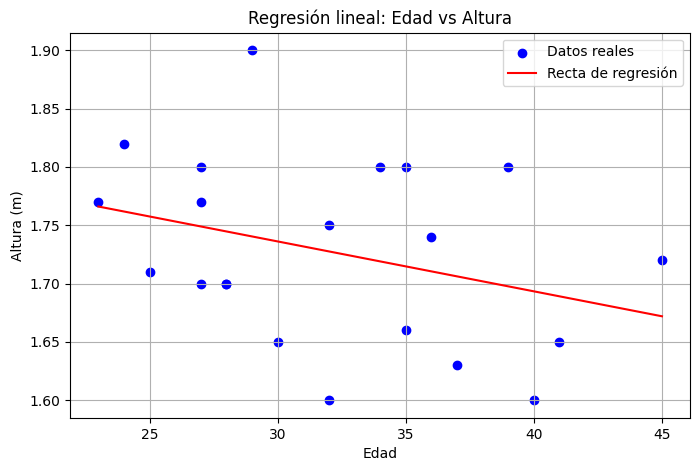

In [26]:
# dibujo recta de regrasión a ver qué sale 
plt.figure(figsize=(8,5))
plt.scatter(df["Edad"], df["Altura"], color="blue", label="Datos reales")

x_line = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
y_line = modelo.predict(x_line)

plt.plot(x_line, y_line, color="red", label="Recta de regresión")
plt.xlabel("Edad")
plt.ylabel("Altura (m)")
plt.title("Regresión lineal: Edad vs Altura")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# puntos muy dispersos y no siguen una tendencia clara
# no se observa un patrón ascendente ni descendente fuerte.
# no existe una relación lineal fuerte entre la edad y la altura

# aunque nube de puntos es dispersa, se aprecia una ligera inclinación descendente
# sinifica que personas algo mayores tienen alturas ligeramente menores
# y personas más jóvenes, tienen alturas ligeramente mayores
# pero la pendiente es muy pequeña, casi plana, mi coef es de -0.004277

# la recta roja baja un poco, pero casi no se nota
# los puntos están lejos de la línea y eso significamala capacidad predictiva
# no hay agrupaciones claras ni estructura, la relación e s débil

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [ ]:
df["Predicción"] = modelo.predict(X)
df["Error"] = df["Altura"] - df["Predicción"]
df["AbsError"] = df["Error"].abs()
df["SqError"] = df["Error"]**2

MAE_manual = df["AbsError"].mean()
MSE_manual = df["SqError"].mean()
RMSE_manual = np.sqrt(MSE_manual)

print("MAE:", MAE_manual) # mide error medio absoluto en metros
print("MSE:", MSE_manual) # penaliza más los errores grandes
print("RMSE:", RMSE_manual) # error típoco del modelo


MAE: 0.0631114830072091
MSE: 0.005299733644745233
RMSE: 0.07279926953442069


In [ ]:
# MAE:
# modelo se equivoca, de media, unos 6 cm al predecir la altura
# para un rango de alturas entre 1.6 y 1.9 m, 6 cm es un error grande

# MSE:
# Un MSE de 0.0053 indica que los errores al cuadrado son pequeños
# confirma lo mismo que el MAE, el modelo no ajusta bien porque no hay relación real entre edad y altura

# RMSE:
# unos 7.3 cm de desviación media

In [32]:
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [ ]:
# métricas sklearn

MAE = metrics.mean_absolute_error(y, df["Predicción"])
MSE = metrics.mean_squared_error(y, df["Predicción"])
RMSE = np.sqrt(MSE) # en vez de poner np.sqrt(metrics.mean_squared_error(y, df["Predicción"]), lo simplifiqué

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)

MAE: 0.0631114830072091
MSE: 0.005299733644745233
RMSE: 0.07279926953442069


In [ ]:
'''
MANUEL:
MAE: 0.0631114830072091
MSE: 0.005299733644745233
RMSE: 0.07279926953442069

SKLEARN:
MAE: 0.0631114830072091
MSE: 0.005299733644745233
RMSE: 0.07279926953442069
'''

# las métricas coinciden exactamente entre el cálculo manual y sklearn